In [1]:
import os
import pandas as pd
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
from datetime import datetime
import glob
from netCDF4 import Dataset
import sys
sys.path.insert(1, '/glade/work/ihtam/wrf-stuff/analysis/')
from util.wrf_process import (calc_derive, object_tracking, read_and_write, perturb)
from util.ml_preprocess import data_preproc
import gc
from tqdm import tqdm
import xarray as xr
import sys
import pickle
from natsort import natsorted
import proplot as plot
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords

def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

/glade/derecho/scratch/ihtam/tmp/ipykernel_39411/3551020489.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')
# CTRL wrfouts
ctrl_files = sorted(glob.glob('/glade/derecho/scratch/ihtam/temp/memb03/wrfout_*'))[:48]

In [8]:
ctrl_files

['/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_12:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_13:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_14:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_15:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_16:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_17:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_18:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_19:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_20:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_21:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_22:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-01_23:00:00',
 '/glade/derecho/scratch/ihtam/temp/memb03/wrfout_d02_2013-11-02_12:00:00',
 '/glade/der

In [9]:
ctrl_axi = []
p_eta_fulls = []
for i in tqdm(range(len(ctrl_files[:]))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix_c, iy_c = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    ix_c = int(ix_c.values)
    iy_c = int(iy_c.values)
    # Calculate IR
    ctrl_RTHRATLW = getvar(nc_ctrl,'RTHRATLW')
    ctrl_RTHRATLWC = getvar(nc_ctrl,'RTHRATLWC')
    ctrl_p = getvar(nc_ctrl, "pressure")
    P  = getvar(nc_ctrl, "P").values   # Pa
    PB = getvar(nc_ctrl, "PB").values  # Pa
    p_eta_fulls.append((P + PB) * 0.01)        # hPa, shape (54, 740, 1200)

    del P, PB
    gc.collect()
    
    ctrl_ir = ctrl_RTHRATLW-ctrl_RTHRATLWC
    # Calculate IR_prime
    ctrl_irp = ctrl_ir-ctrl_ir.mean(axis=(1,2))
    #-------------------------------------------------------------------
    #                     Get Azimuthal Mean
    #-------------------------------------------------------------------
    dx = nc_ctrl.DX  # km
    dy = nc_ctrl.DY  # km
    ny, nx = ctrl_irp.shape[-2:]  # or any 2D field variable
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)
    azm = perturb.azimuthal_mean_3d(ctrl_irp, ix_c, iy_c, dx, dy, rmax_km=600, dr_km=3)
    azm_pres = perturb.azimuthal_mean_3d(ctrl_p, ix_c, iy_c, dx, dy, rmax_km=600, dr_km=3)
    p_levels = np.array([1000, 950, 900, 850, 800, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250, 200, 150, 100, 50])
    azim_field_p = perturb.vertical_interp_to_p(azm, azm_pres, p_levels)
    ctrl_axi.append(azim_field_p)

100%|██████████| 48/48 [03:49<00:00,  4.78s/it]


In [20]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': True, # Remove right spine
    'axes.spines.top': True,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 10,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_39411/3612073026.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


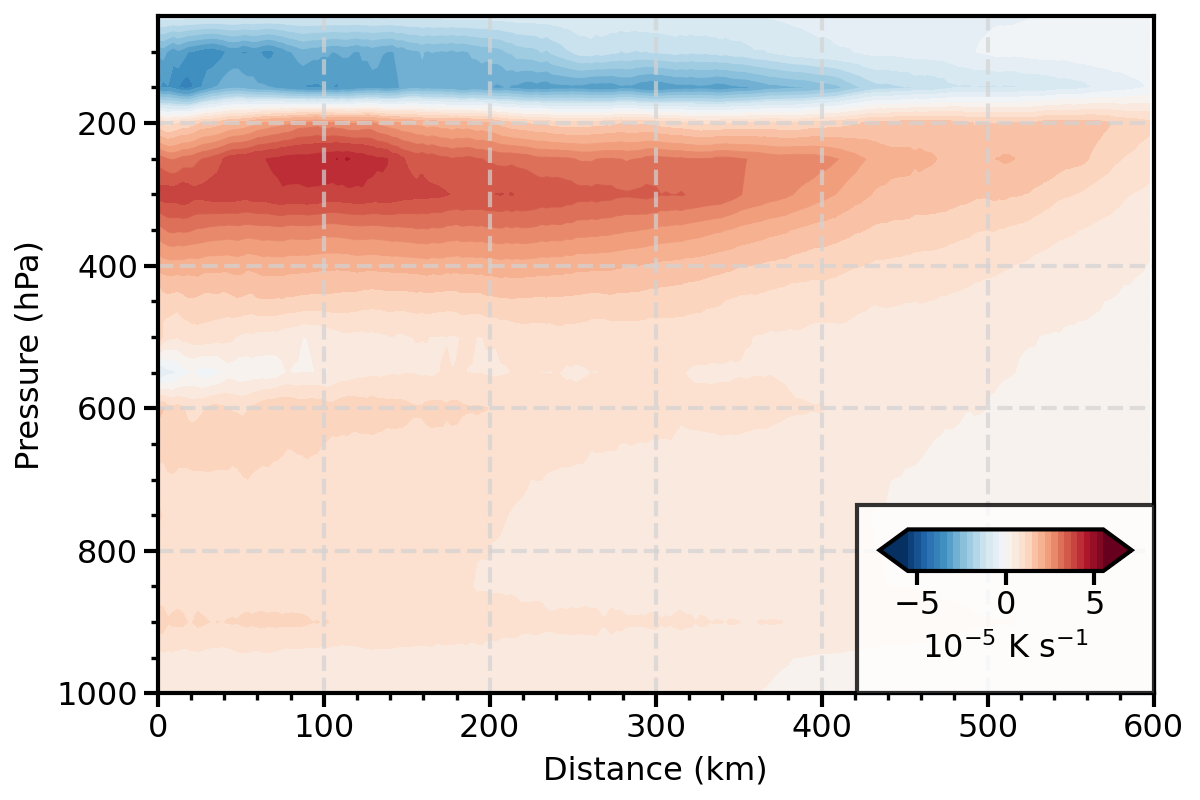

In [31]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(np.linspace(0,199,200)*3,p_levels,np.asarray(ctrl_axi).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,50),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()

## With Dipole

In [22]:
# Temporal mean to fit
F = np.asarray(ctrl_axi).mean(axis=0).transpose()

# existing 4 + two core Gaussians
n_comp = 7
# signs: keep your outer "upper cooling" negative; make the inner cool negative too
#signs = ['free','free','free','neg','free','neg']  # comps 1..6
signs = ['free','free','free','free','free','neg','neg']  # last one for upper-level coolingn_comp = 4

# seeds you already have for 1..4
#seeds = {
#    'b':  np.nanmedian(F),
#    'p1': 900., 'r1': 200., 'sp1':  40., 'sr1': 140., 'C1': max(1e-6, float(np.nanpercentile(F,95)-np.nanmedian(F))),
#    'p2': 420., 'r2': 360., 'sp2': 120., 'sr2': 250., 'C2': max(1e-6, float(np.nanpercentile(F,90)-np.nanmedian(F))),
#    'p3': 600., 'r3': 200., 'sp3': 120., 'sr3': 250., 'C3': 0.5*(float(np.nanpercentile(F,95)-np.nanmedian(F))),
#    'p4': 200., 'r4': 360., 'sp4':  60., 'sr4': 420., 'g4': np.log(max(1e-6, float(np.nanmedian(F)-np.nanmin(F)))),
#    # NEW: core warm (≈300–350 hPa, r<200 km)
#    'p5': 330., 'r5':  80., 'sp5': 70., 'sr5': 70., 'C5': 0.4*float(np.nanpercentile(F,95)-np.nanmedian(F)),
#    # NEW: core cool (≈120–180 hPa, r<200 km)
#    'p6': 160., 'r6':  60., 'sp6': 60., 'sr6': 60., 'g6': np.log(max(1e-6, 0.3*float(np.nanpercentile(F,95)-np.nanmedian(F)))),
#}

seeds = {
    'b': np.nanmedian(F),

    # 1. Low-level warm (~900 hPa)
    'p1': 900., 'r1': 150.,
    'sp1': 50., 'sr1': 120.,
    'C1': 0.8e-5,

    # 2. Lower-mid warm (~600 hPa)
    'p2': 600., 'r2': 200.,
    'sp2': 80., 'sr2': 180.,
    'C2': 1.6e-5,

    # 3. Main warm (~400 hPa)
    'p3': 400., 'r3': 150.,
    'sp3': 100., 'sr3': 180.,
    'C3': 3.0e-5,

    # 4. Outer warm (~350 hPa)
    'p4': 350., 'r4': 350.,
    'sp4': 120., 'sr4': 250.,
    'C4': 2.0e-5,

    # 5. Inner warm (~300 hPa)
    'p5': 300., 'r5': 60.,
    'sp5': 70., 'sr5': 70.,
    'C5': 1.2e-5,

    # 6. Upper cooling (~180 hPa)
    'p6': 180., 'r6': 250.,
    'sp6': 80., 'sr6': 250.,
    'g6': np.log(3.0e-5),

    # 7. Inner upper cooling (~150 hPa)
    'p7': 150., 'r7': 80.,
    'sp7': 60., 'sr7': 80.,
    'g7': np.log(2.0e-5),
}

# component-specific bounds to confine the inner dipole:
comp_bounds = {
    5: (0.0, 250.0, 50.0, 400.0),  # comp5 inside r<=200 km and 100–400 hPa
    6: (0.0, 250.0, 50.0, 400.0),
}

# grids
r_km = np.linspace(0, 199, 200) * 3.0  # your r
# p_levels = ... (your pressure vector); F is Ω(p,r) as in your snippet

params, F_fit, res = perturb.fit_gaussians_pr(
    r_km, p_levels, F, n_comp=n_comp,
    seeds=seeds, signs=signs, comp_bounds=comp_bounds,
    robust=True, max_nfev=6000
)

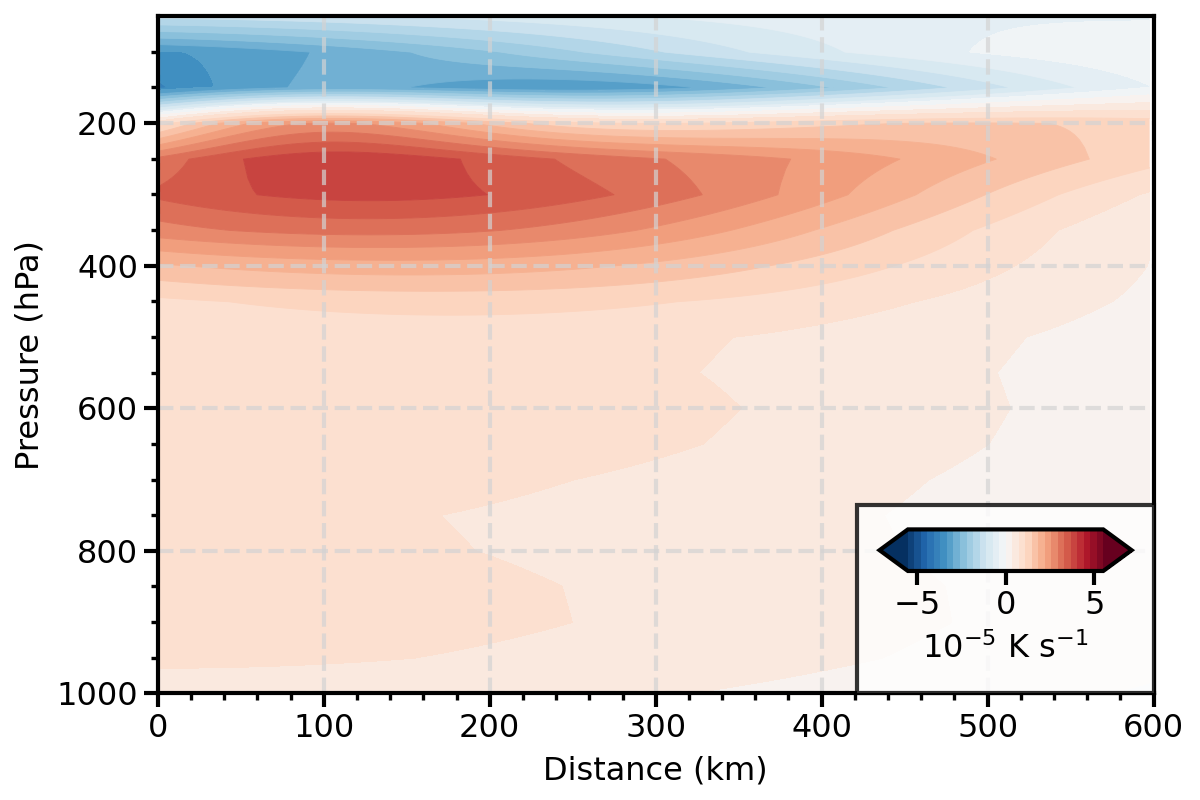

In [32]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(np.linspace(0,199,200)*3,p_levels,F_fit*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,50),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
plt.savefig('./haiyan_sen/pics/2day_CRFavg_params.png',dpi=400)
plt.show()

In [29]:
F_fit_bal, beta, B  = perturb.add_negative_background_to_zero_mean(r_km, p_levels, F_fit, radial_only=False)

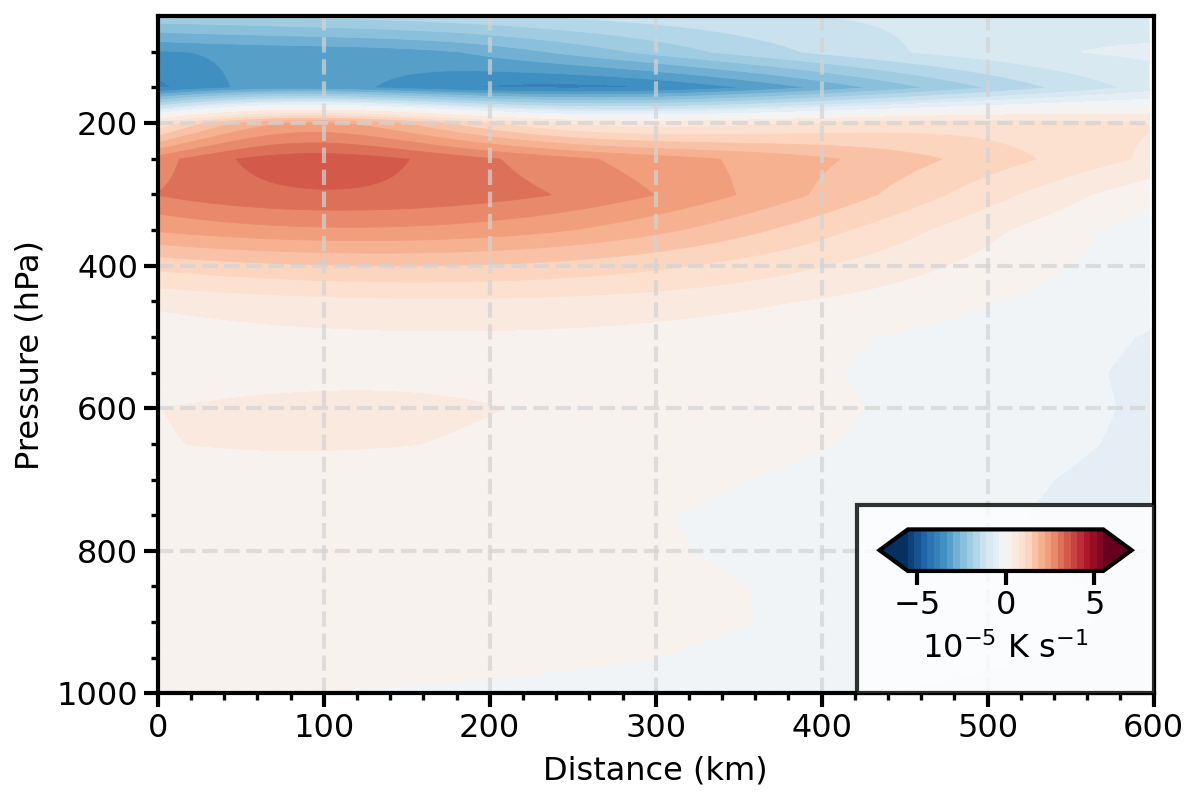

In [33]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(np.linspace(0,199,200)*3,p_levels,F_fit_bal*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,50),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
plt.savefig('./haiyan_sen/pics/2day_CRFavg_params_adjusted.png',dpi=400)
plt.show()

## Shear

In [34]:
proc_U = xr.open_dataset("./U_HiRes.nc")
proc_V = xr.open_dataset("./V_HiRes.nc")

In [35]:
Xs = []
ys = []
weshape = ctrl_RTHRATLW.shape[2]
nsshape = ctrl_RTHRATLW.shape[1]
domainradius = int(800/3)
for i in range(len(track_memb03['clat'])):
    x,y = ll_to_xy(nc_ctrl, track_memb03['clat'][i], track_memb03['clon'][i], as_int=True)
    if ((weshape-x)>domainradius) and ((nsshape-y)>domainradius):
        Xs.append(int(x.values))
        ys.append(int(y.values))
    else:
        Xs.append(np.nan)
        ys.append(np.nan)

/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/wrf/latlonutils.py:434: RuntimeWarning: invalid value encountered in cast
  result = np.rint(result).astype(int)
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/wrf/latlonutils.py:434: RuntimeWarning: invalid value encountered in cast
  result = np.rint(result).astype(int)


In [36]:
shear_mags,shear_dirs = [],[]
for i in range(len(track_memb03['clat'])):
    if Xs[i]==np.nan:
        shear_mags.append(np.nan)
        shear_dirs.append(np.nan)
    else:
        shear_u, shear_v, shear_mag = perturb.compute_tc_shear(proc_U['U'][i,...], proc_V['V'][i,...], list(proc_U['pres'].data), Xs[i], ys[i], dx_km=3.0,
                                                       inner_km=200.0, outer_km=800.0,
                                                       p_top=200.0, p_bot=850.0)
        shear_mags.append(shear_mag)
        shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))

del proc_U, proc_V
gc.collect()

/glade/work/ihtam/wrf-stuff/analysis/util/wrf_process/perturb.py:128: RuntimeWarning: Mean of empty slice
  u200m = np.nanmean(to_np(u200.where(mask)))
/glade/work/ihtam/wrf-stuff/analysis/util/wrf_process/perturb.py:129: RuntimeWarning: Mean of empty slice
  v200m = np.nanmean(to_np(v200.where(mask)))
/glade/work/ihtam/wrf-stuff/analysis/util/wrf_process/perturb.py:130: RuntimeWarning: Mean of empty slice
  u850m = np.nanmean(to_np(u850.where(mask)))
/glade/work/ihtam/wrf-stuff/analysis/util/wrf_process/perturb.py:131: RuntimeWarning: Mean of empty slice
  v850m = np.nanmean(to_np(v850.where(mask)))


16414

## Generate time stamps

In [13]:
import importlib
importlib.reload(perturb)

<module 'util.wrf_process.perturb' from '/glade/work/ihtam/wrf-stuff/analysis/util/wrf_process/perturb.py'>

In [14]:
import pandas as pd

# Define start and end datetimes
t0 = pd.Timestamp("2013-11-01 00:00:00")
t1 = pd.Timestamp("2013-11-05 00:00:00")

# Generate 1-hr steps (end inclusive)
times_1hr = pd.date_range(start=t0, end=t1, freq="1h")
# Generate 3-min steps (end inclusive)
times_3min = pd.date_range(start=t0, end=t1, freq="3min")

# Format as WRF-style strings
times_str_3min = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_3min]
time_str_1hr = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_1hr]

In [15]:
Xs_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(Xs))
ys_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(ys))
sheardirs_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(shear_dirs))

In [16]:
def omega_to_xy_with_cos(F_pr, r_km, p_hpa,
                         x_km, y_km, x0_km, y0_km,
                         phi0_deg=0.0, mode='wn1'):
    """
    Expand azimuthal-mean Ω(p,r) to Ω(p,y,x) with optional cos(theta-phi0).

    Parameters
    ----------
    F_pr : 2D array (p, r)
        Your fitted field on pressure × radius.
    r_km : 1D array [km] of radii used in F_pr.
    p_hpa: 1D array [hPa] of pressures used in F_pr.
    x_km, y_km : 1D arrays [km] horizontal model coords.
    x0_km, y0_km : floats [km] TC center.
    phi0_deg : float
        Phase angle; 0° points EAST and increases counter-clockwise.
    mode : {'wn1','wn0'}
        'wn1' → multiply by cos(theta-phi0); 'wn0' → no azimuthal term.

    Returns
    -------
    Ω_pyx : xarray.DataArray with dims ('p','y','x')
    """
    F_pr = np.asarray(F_pr)
    r_km = np.asarray(r_km); p_hpa = np.asarray(p_hpa)
    x_km = np.asarray(x_km); y_km = np.asarray(y_km)

    # horizontal geometry w.r.t. TC center
    X, Y = np.meshgrid(x_km, y_km, indexing='xy')
    dx = X - x0_km
    dy = Y - y0_km
    r_xy = np.sqrt(dx*dx + dy*dy)                # [km]
    theta = np.arctan2(dy, dx)                   # 0 along +x (east), CCW positive
    # phase (convert degrees → radians)
    phi0 = np.deg2rad(phi0_deg)
    if mode.lower() == 'wn1':
        A_theta = np.cos(theta - phi0)
    elif mode.lower() == 'wn0':
        A_theta = 1.0
    else:
        raise ValueError("mode must be 'wn1' or 'wn0'.")

    # radial interpolation for each pressure level (vectorized np.interp)
    # F_pr is (p,r); we interpolate along r for each p to r_xy
    F_pyx = np.empty((len(p_hpa), len(y_km), len(x_km)), dtype=float)
    rmin, rmax = float(r_km.min()), float(r_km.max())
    r_clipped = np.clip(r_xy, rmin, rmax)

    for ip, pval in enumerate(p_hpa):
        Fr = F_pr[ip, :]                         # (r,)
        F_pyx[ip, :, :] = np.interp(r_clipped, r_km, Fr, left=Fr[0], right=Fr[-1])

    # apply azimuthal structure
    F_pyx *= A_theta[np.newaxis, :, :]

    return xr.DataArray(
        F_pyx, coords={'p': p_hpa, 'y': y_km, 'x': x_km},
        dims=('p','y','x'), name='Omega_with_cos'
    )

In [17]:
r_km = np.linspace(0, 199, 200) * 3.0   # 0 … 798 km in 3-km steps
dx_km = dy_km = 3.0
r_max = float(r_km[-1])  # 798 km

# minimal square grid that spans at least r_max in all directions
half_span = r_max               # 798 km
nx = ny = int(np.floor(2*half_span/dx_km)) + 1  # ~ (2*798/3)+1 ≈ 533
x_km = np.arange(-half_span, half_span + 1e-9, dx_km)
y_km = np.arange(-half_span, half_span + 1e-9, dy_km)

# storm-centered coordinates → center is (0, 0)
x0_km = 0.0
y0_km = 0.0

In [29]:
Ps = []
t_cutoff = len(pd.date_range(start=t0, end=pd.Timestamp("2013-11-05 00:00:00"), freq="3min"))
p_src_hPa = [1000, 950, 900, 850, 800, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250, 200, 150, 100, 50]

for i in tqdm(range(t_cutoff)):
    if np.isnan(sheardirs_3min[i]):
        #Ps.append(np.nan)
        read_and_write.save_to_pickle(np.nan,f'../perturb/wrf_memb3_wn1_4days_eta_{i}.pkl')
    else:
        # 1. Generate 39-level perturbation
        P39 = omega_to_xy_with_cos(
            F_fit_bal, np.linspace(0,199,200)*3,p_levels,
            x_km, y_km, x0_km, y0_km,
            phi0_deg=sheardirs_3min[i], mode='wn1'   # set 'wn0' for the monopole case
        )

        # 2. Get eta pressures for this block (54,416,416) from wrfinput
        #    (you’ll need to pick the right subdomain later, but if you just want
        #     to remap the core block for now, slice out the center)
        # Example: center domain indices around (ys_3min[i], Xs_3min[i])
        y0i = int(np.round(ys_3min[i]))
        x0i = int(np.round(Xs_3min[i]))
        try:
            p_eta_block = p_eta_fulls[i//20][:, y0i-200:y0i+199, x0i-200:x0i+199]
        except:
            p_eta_block = p_eta_fulls[-1][:, y0i-200:y0i+199, x0i-200:x0i+199]
        
        # 3. Remap to eta levels
        P54 = perturb.remap_to_eta_fast(P39, p_src_hPa, p_eta_block, fill_value=0.0)

        # 4. Store
        #Ps.append(P54 * -1)  # perturbation sign
        read_and_write.save_to_pickle(P54 * -1,f'../perturb/wrf_memb3_wn1_4days_eta_{i}.pkl')

100%|██████████| 1921/1921 [16:59<00:00,  1.88it/s]


In [47]:
HAHAHA = read_and_write.depickle(f'../perturb/wrf_memb3_wn1_4days_eta_{0}.pkl')

In [ ]:
n_time = 1921
t_cutoff = len(pd.date_range(start=t0, end=pd.Timestamp("2013-11-04 00:00:00"), freq="3min"))

with Dataset("LWPERTIN.nc", "w", format="NETCDF4") as nc:
    # ------------------------
    # Define dimensions (WRF style)
    # ------------------------
    nc.createDimension("Time", n_time)
    nc.createDimension("DateStrLen", 19)
    nc.createDimension("bottom_top", 54)     # <-- use 54 if remapped to eta
    nc.createDimension("south_north", 740)
    nc.createDimension("west_east", 1200)

    # ------------------------
    # Times variable
    # ------------------------
    times_var = nc.createVariable("Times", "S1", ("Time", "DateStrLen"))
    for it, tstamp in enumerate(times_str_3min):
        date_str = tstamp  # already formatted "YYYY-MM-DD_HH:MM:SS"
        times_var[it, :] = np.array(list(date_str), dtype="S1")

    # ------------------------
    # Perturbation variable
    # ------------------------
    lwpertin = nc.createVariable(
        "LWPERTIN", "f4",
        ("Time", "bottom_top", "south_north", "west_east"),
        zlib=True, complevel=4, chunksizes=(1, 1, 416, 416)
    )

    # WRF-style metadata
    lwpertin.FieldType   = 104
    lwpertin.MemoryOrder = "XYZ"
    lwpertin.units       = ""
    lwpertin.description = "LW perturbation field"
    lwpertin.stagger     = ""

    # ------------------------
    # Loop over time
    # ------------------------
    for it, tstamp in enumerate(tqdm(times_str_3min)):
        perturb  = read_and_write.depickle(f'../perturb/wrf_memb3_wn1_4days_eta_{it}.pkl')
        if it < t_cutoff:
            if np.isnan(Xs_3min[it]):
                lwpertin[it, :, :, :] = 0.0
                continue
            block = perturb.astype("float32")  # should be (54, 416, 416) now
            xloc = int(np.round(Xs_3min[it]))
            yloc = int(np.round(ys_3min[it]))
            lwpertin[it, :, yloc-200:yloc+199, xloc-200:xloc+199] = block
        else:
            lwpertin[it, :, :, :] = 0.0

100%|█████████▉| 1920/1921 [33:40<00:00,  1.09it/s] 

In [40]:
temp = read_and_write.depickle(f'../perturb/wrf_memb3_wn1_4days_eta_{240}.pkl')
preturb = [interplevel(temp, ctrl_p[:,740//2-200:740//2+199,600-200:600+199], pres) for pres in [1000,900,800,700,600,500,400,300,200,100]]
read_and_write.save_to_pickle(preturb,f'./haiyan_sen/011123_12UTC_perturbLW.pkl')

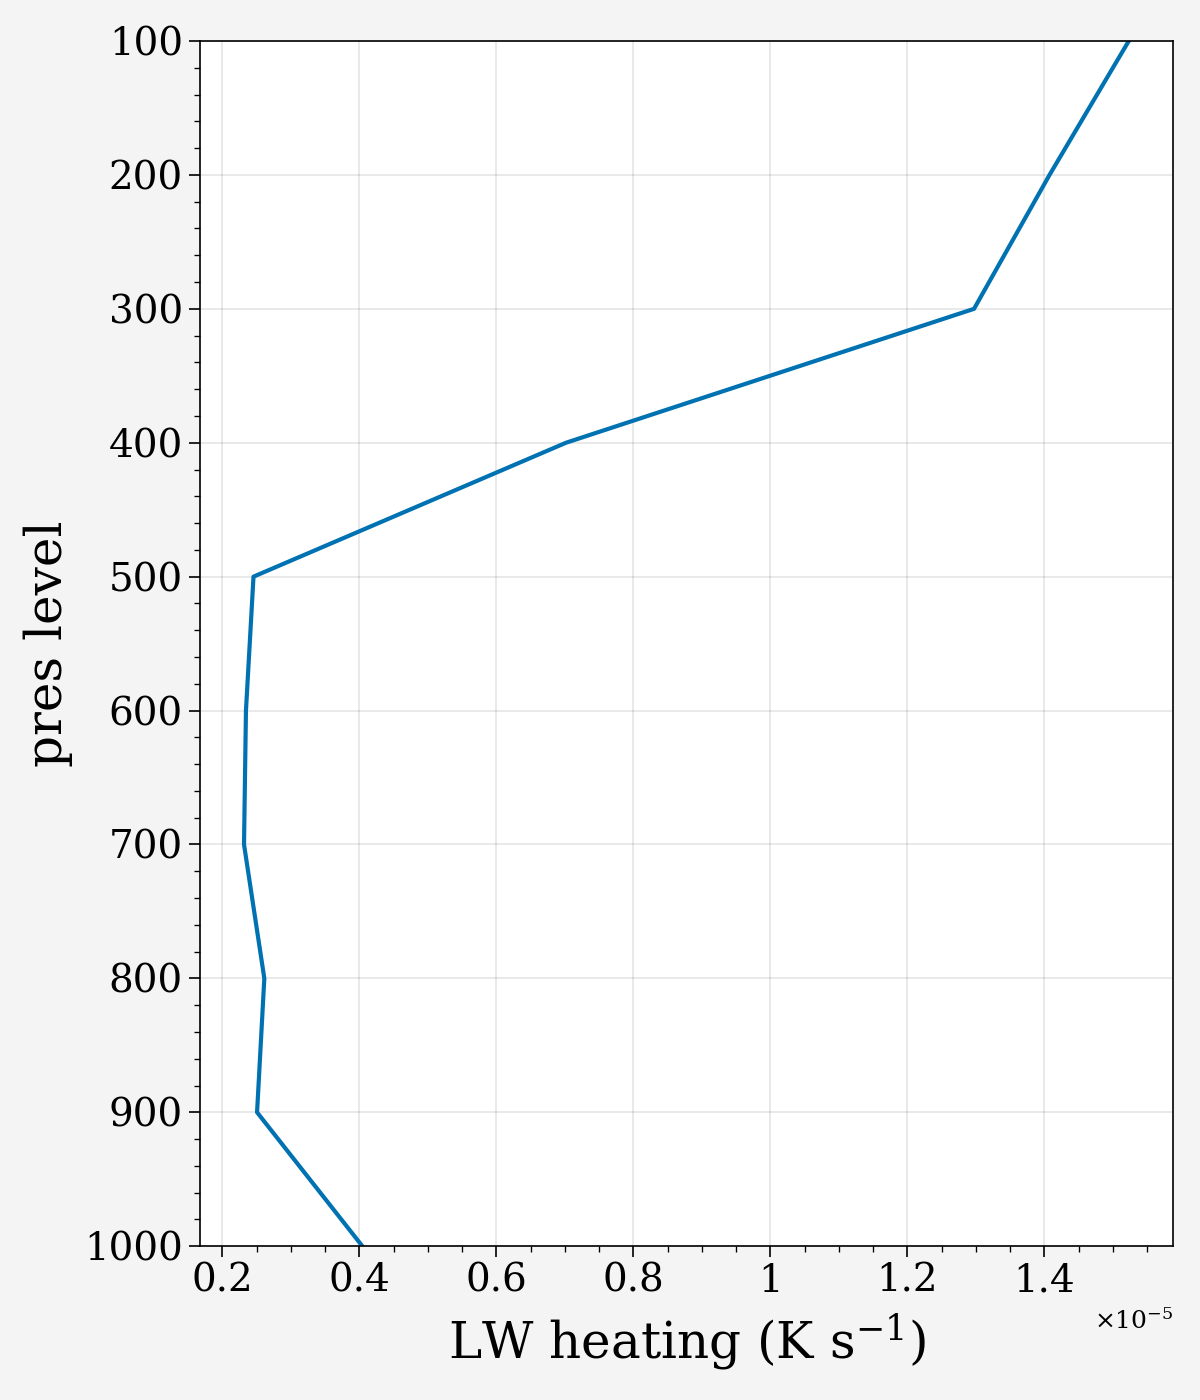

In [13]:
fig,ax = plt.subplots(1,1,figsize=(6,7))
plt.plot(np.nanmax(np.asarray(preturb),axis=(1,2)),[1000,900,800,700,600,500,400,300,200,100])
plt.ylim(1000,100)
plt.ylabel('pres level',size=18)
plt.xlabel('LW heating (K s$^{-1}$)',size=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

In [23]:
temp = xr.open_dataset('../wrflowinp_d02',engine='netcdf4')

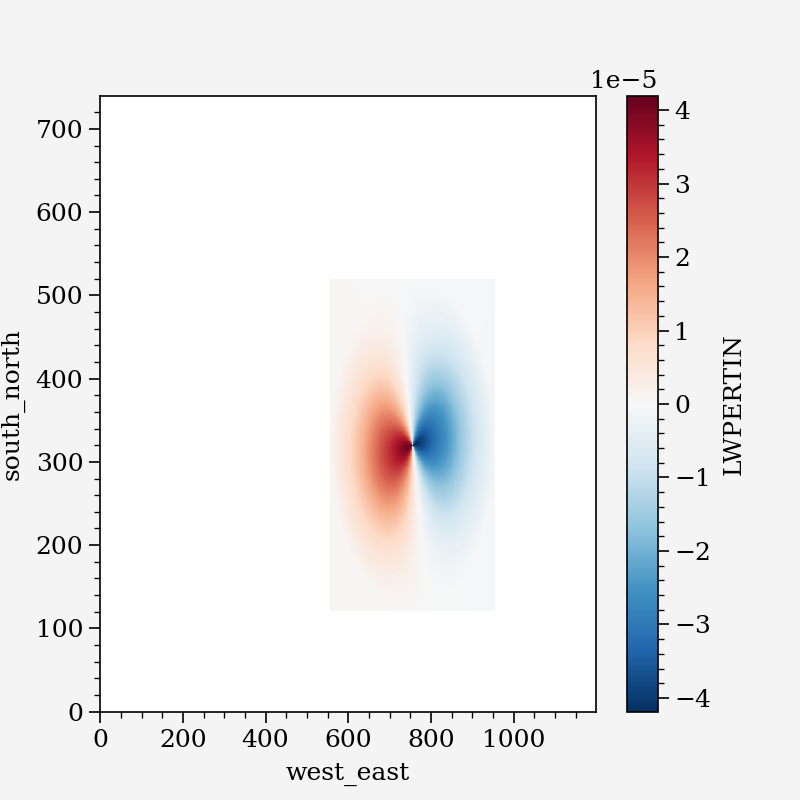

In [30]:
temp['LWPERTIN'][200][30,...].plot()

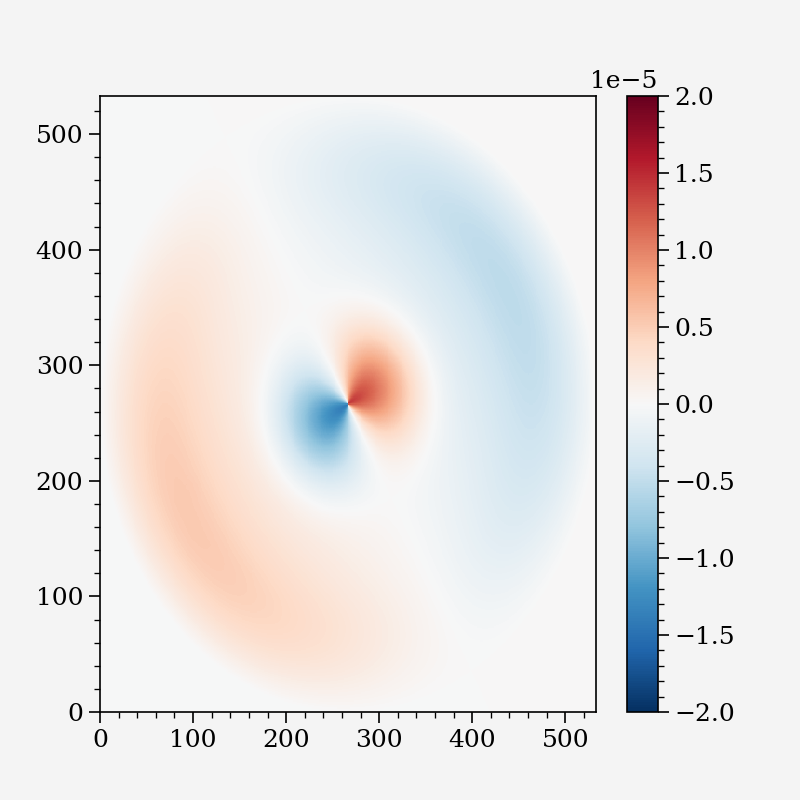

In [29]:
plt.pcolormesh(preturb[8],vmin=-2e-5,vmax=2e-5,cmap='RdBu_r')
plt.colorbar()
plt.show()